## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.


1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [4]:
crosstab_1 = pd.crosstab(df["category"], df["isBestSeller"])
crosstab_1

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [21]:
crosstab_1_prop = crosstab_1
crosstab_1_prop["proportion"]= (crosstab_1[True]/(crosstab_1[True]+crosstab_1[False])*100)
crosstab_1_prop.sort_values("proportion",ascending=False)

isBestSeller,False,True,proportion
category,,,
Grocery,9008,556,5.813467
Smart Home Security & Lighting,98,6,5.769231
Health & Personal Care,9017,552,5.768628
Mobile Phone Accessories,248,11,4.247104
Power & Hand Tools,8353,306,3.533895
...,...,...,...
Bedding Collections,6309,0,0.000000
CPUs,249,0,0.000000
"CD, Disc & Tape Players",8798,0,0.000000


In the following category there is a higher prevalence of best sellers:
- Grocery
- Smart Home Security & Lighting
- Health & Personal Care
- Mobile Phone Accessories
and Power & Hand Tools.

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [5]:
from scipy.stats import chi2_contingency

In [7]:
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_1)
a,b,c,d=chi2_contingency(crosstab_1)

In [ ]:
float(chi2_pvalue) 

0.0

The Chi p-value is smaller than 0.5. Therefore we do have a statistical evidence that best sellers and product category are not independent.

In [11]:
from scipy.stats.contingency import association

In [12]:
association(crosstab_1, method='cramer')

0.1222829439760564

The Cramér’s V association is weak, as it is between 0.10 and 0.20. This suggests that there is only a weak association between best-seller status and product category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

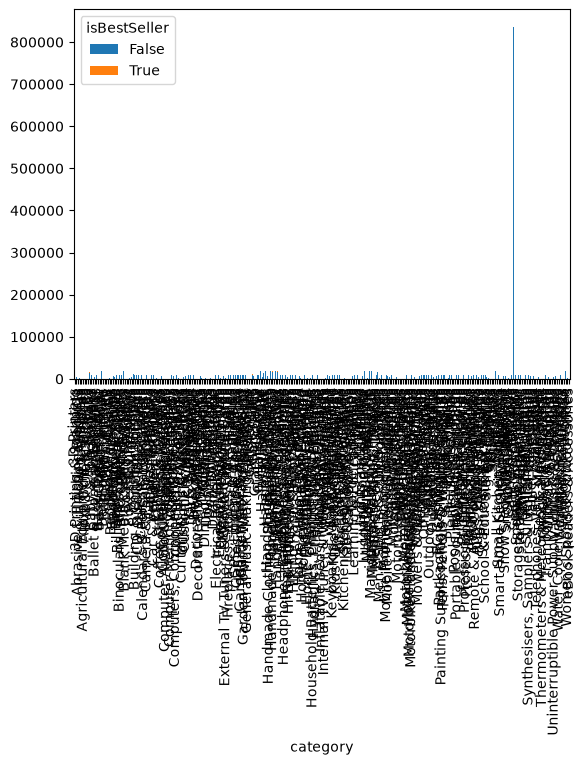

In [10]:
crosstab_1.plot(kind='bar', stacked=True)
plt.show()

The stacked bar chart is hard to read, because of the large number of product categories. It is though evident, that for one product category there is a high number of products, that are not bestsellers.

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.


0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [18]:
def outlier_remove(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds for the outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data

In [ ]:
data_clean = outlier_remove(df,"price")
data_clean

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

In [32]:
frequency_list = data_clean.category.value_counts().sort_values(ascending=False) 
top_20_list = frequency_list.head(20).index 
top_20_subset = df[df["category"].isin(top_20_list)] 

C:\Users\zoed\AppData\Local\Temp\ipykernel_38884\3906857852.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top_20_subset, x="category", y="price", palette="viridis")


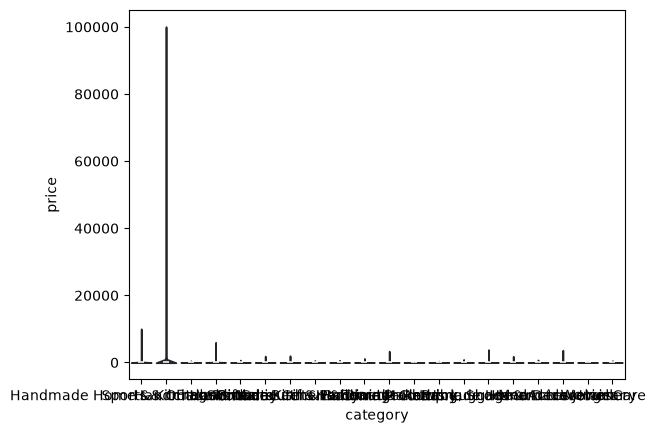

In [33]:
sns.violinplot(data=top_20_subset, x="category", y="price", palette="viridis")
plt.show()

Even with the subset and the clean data the violin plot is still very hard to read. On category seems to have high priced items. 

In [39]:
median_price = data_clean.groupby("category")["price"].agg(["median"]).round(2).sort_values("median", ascending=False)
median_price

,median
category,
Desktop PCs,74.00
Boxing Shoes,69.79
Tablets,69.00
Graphics Cards,68.54
Motherboards,67.92
...,...
Adapters,7.05
Make-up,7.00
Signs & Plaques,6.99


The category "Desktops PCs" seems to have the highest median price, with a median price of 74.00.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

In [42]:
top_10_list = frequency_list.head(10).index 
top_10_subset = df[df["category"].isin(top_20_list)] 
mean_price = top_10_subset.groupby("category")["price"].agg(["mean"]).round(2).sort_values("mean", ascending=False)

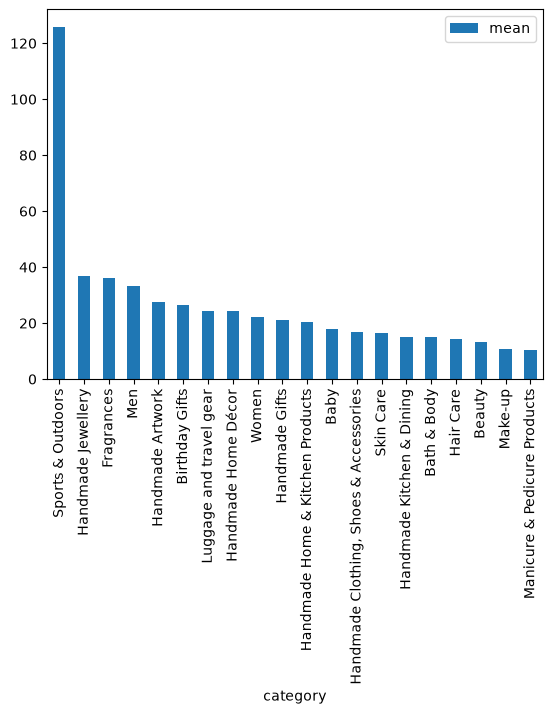

In [43]:
mean_price.plot(kind='bar', stacked=False)
plt.show()

The category "Sports & Outdoos" has the highest average price in the top 10 categorys.

In [46]:
mean_price_total = data_clean.groupby("category")["price"].agg(["mean"]).round(2).sort_values("mean", ascending=False)
mean_price_total

,mean
category,
Motherboards,68.77
Boxing Shoes,67.42
Desktop PCs,66.92
Tablets,66.55
Graphics Cards,65.10
...,...
Bedding Accessories,8.84
Adapters,8.75
Signs & Plaques,8.21


Comparing all category motherboards have the highest mean price.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

C:\Users\zoed\AppData\Local\Temp\ipykernel_38884\4115502776.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_10_subset, x="category", y="stars", palette="viridis", legend=False)


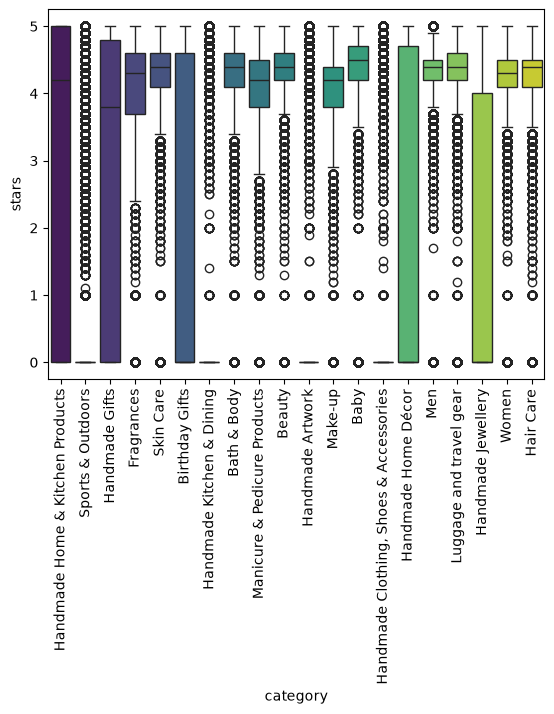

In [48]:
sns.boxplot(data=top_10_subset, x="category", y="stars", palette="viridis", legend=False)
plt.xticks(rotation=90)
plt.show()

In [49]:
median_rating = data_clean.groupby("category")["stars"].agg(["median"]).round(2).sort_values("median", ascending=False)
median_rating

,median
category,
Computer Memory,4.7
"Beer, Wine & Spirits",4.6
Building & Construction Toys,4.6
Office Paper Products,4.6
Kids' Play Figures,4.6
...,...
"Synthesisers, Samplers & Digital Instruments",0.0
Tablets,0.0
Action Cameras,0.0


The category "Computer Memory" has the highest median rating.

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [52]:
round(float(data_clean["price"].corr(df["stars"], method="spearman")), 2)

-0.07

The Spearman correlation coefficient is of -0.08, which shows a slight negative correlation between price and rating. The result beeing close to zero shows, that there is almost no meaningful monotonic relationship between price and rating.

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

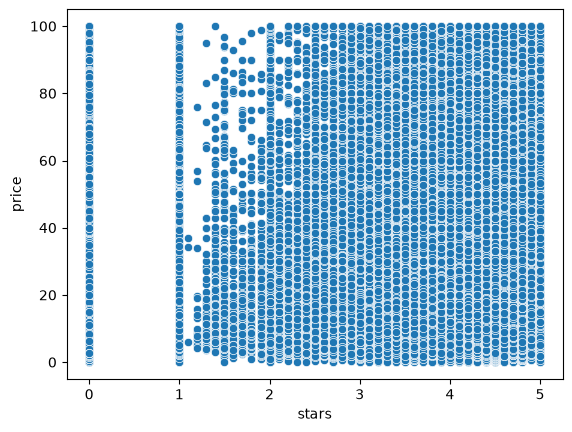

In [54]:
sns.scatterplot(data=data_clean, x='stars', y='price')
plt.show()

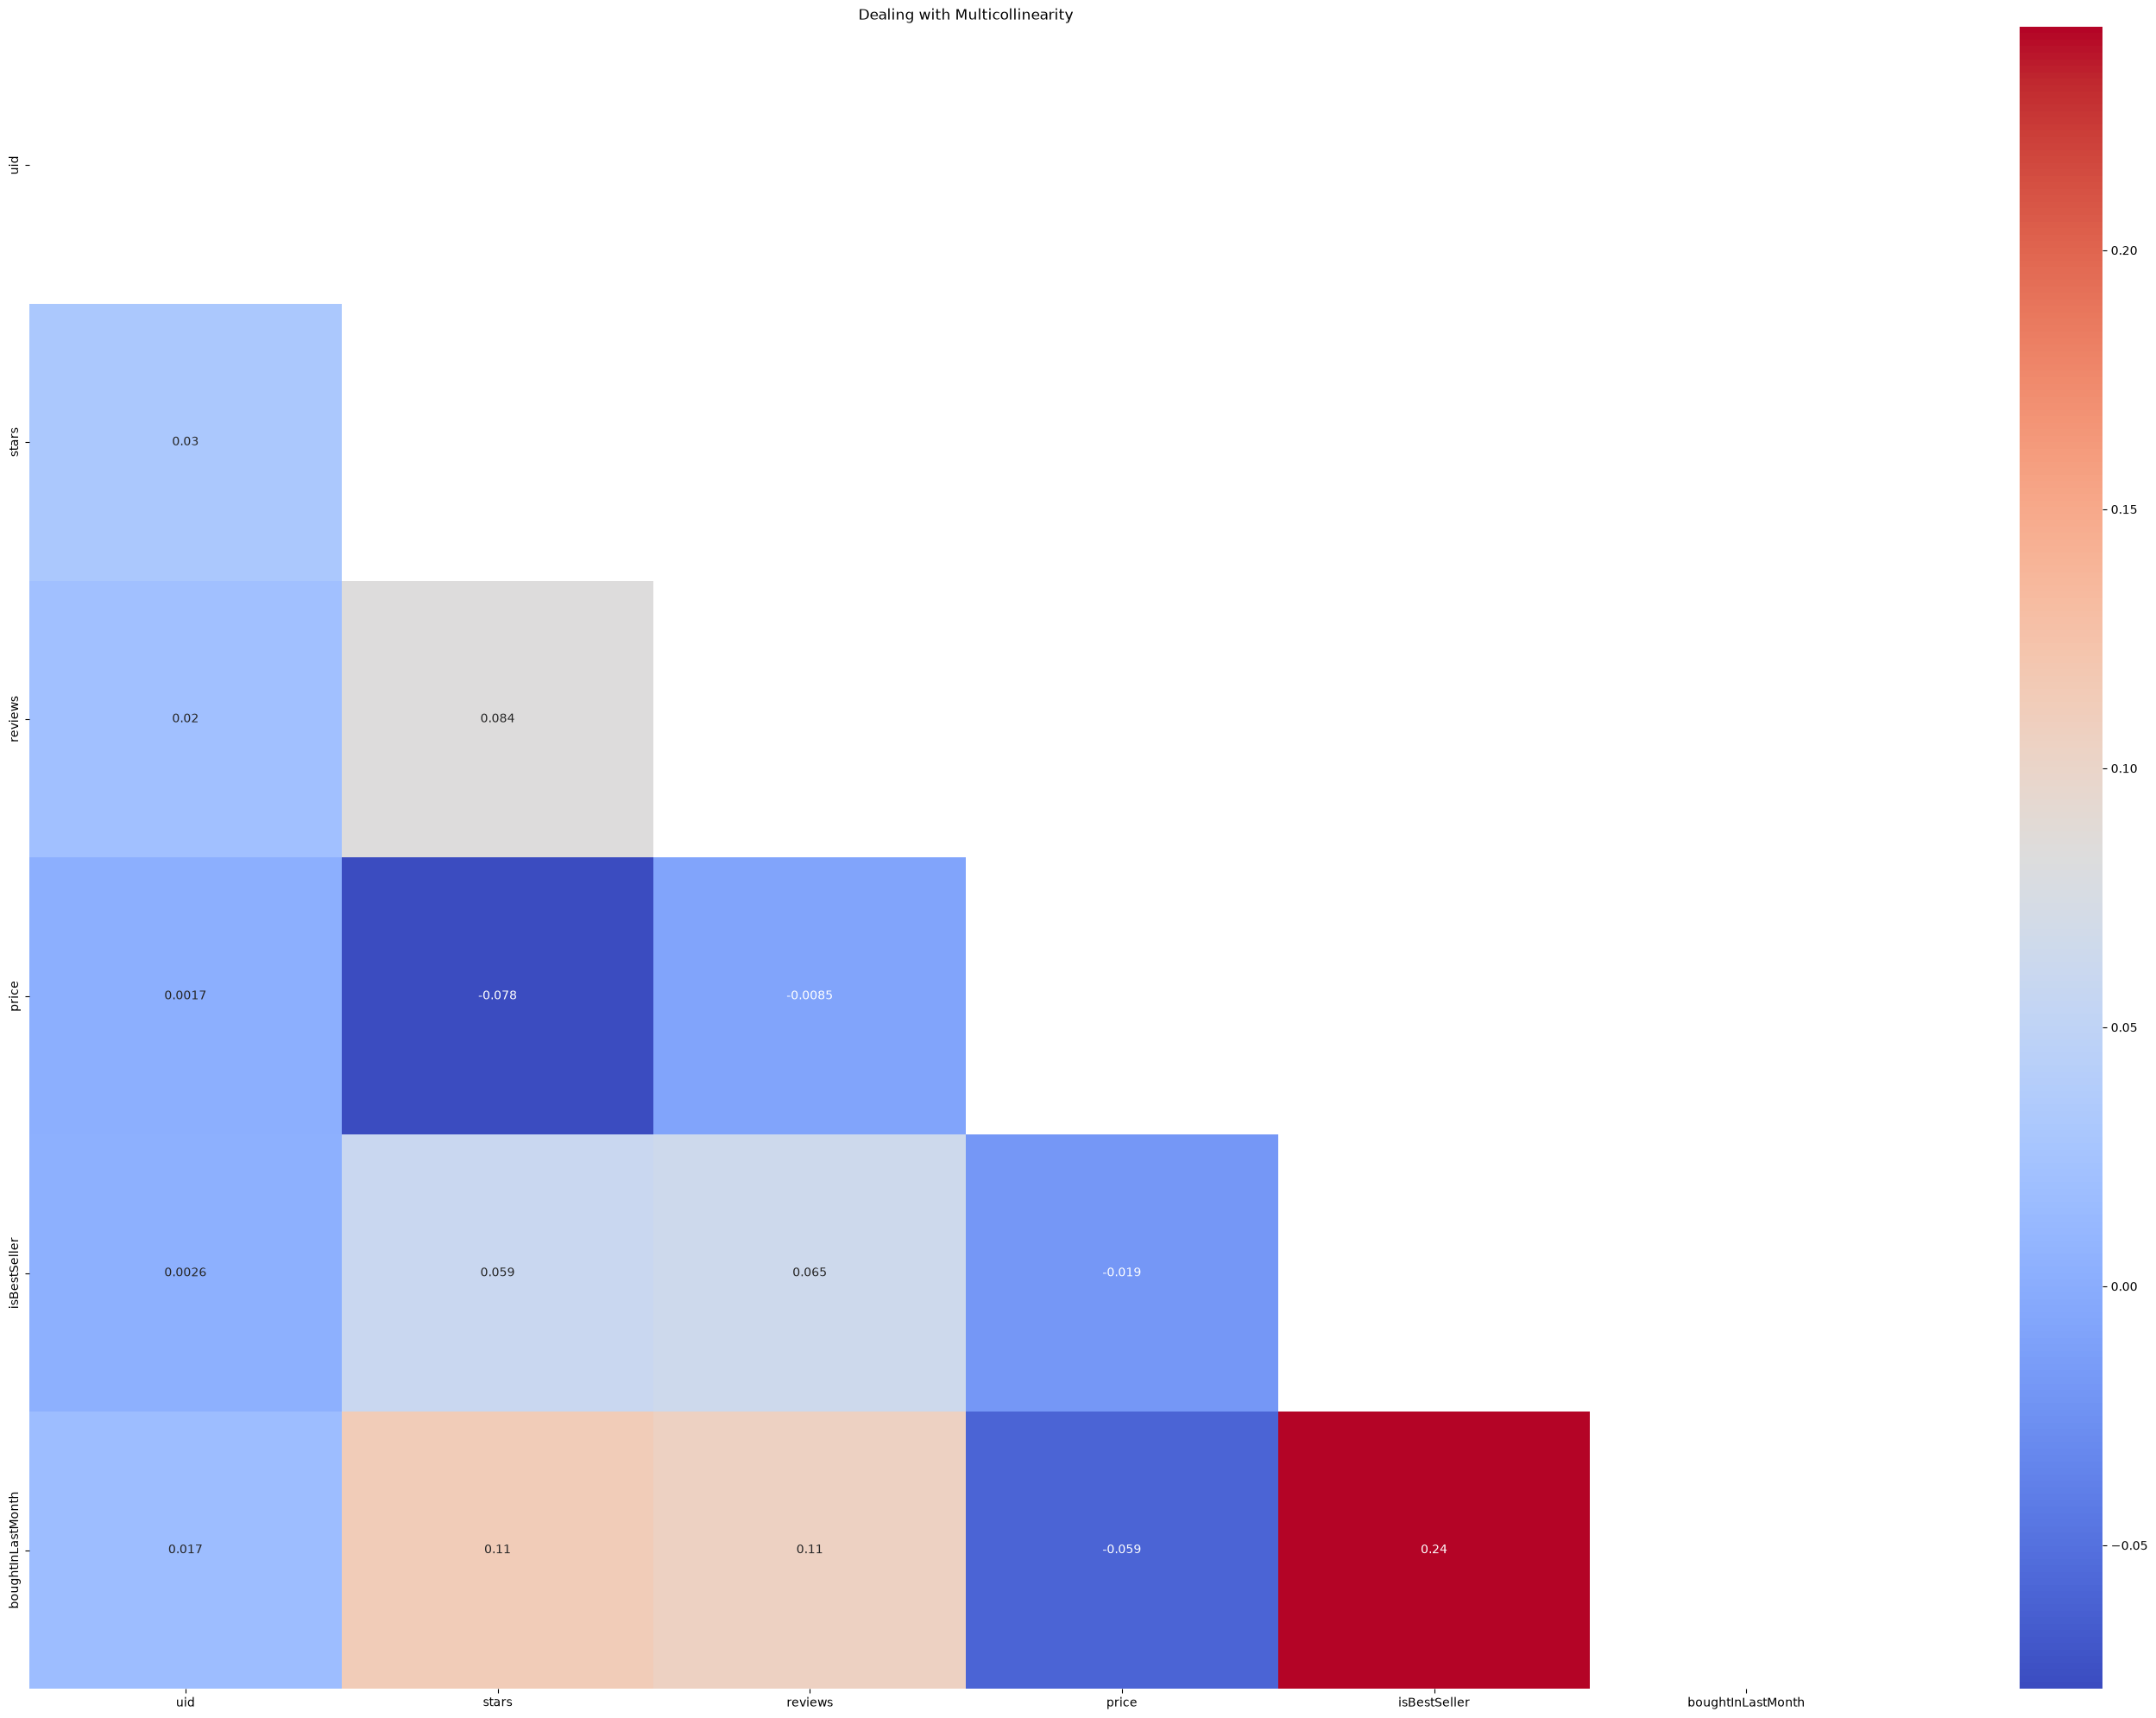

In [61]:
correlation_matrix = data_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(35, 25))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm")

plt.title("Dealing with Multicollinearity")
plt.show()

The heat map shows a strong raltionship between the best sellers ans the products, that were bought last month.

In [64]:
import statsmodels.api as sm

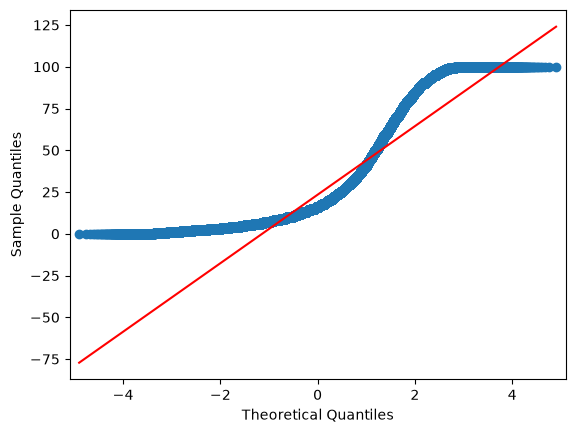

In [65]:
sm.qqplot(data_clean['price'], line='s');
plt.show()

The price does not follow a normal distribuion.

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?